# C9 Bài tập thực hành - Advanced deep learning for computer vision
**Chương 9 - Học sâu nâng cao cho thị giác máy tính**

Mục tiêu của bài thực hành:

- Phân biệt **classification**, **semantic segmentation** và **object detection**.
- Tự xây pipeline dữ liệu cho bài toán **semantic segmentation**.
- Xây mô hình segmentation dạng **encoder-decoder** với `Conv2D` và `Conv2DTranspose`.
- Thực hành các mẫu kiến trúc: **residual connection**, **BatchNormalization**, **SeparableConv2D**.
- Trực quan hóa **intermediate activations** và **filter patterns** để hiểu convnet học gì.

Quy ước: các vị trí cần làm được đánh dấu bằng `TODO`. Sinh viên hoàn thành từng cell theo thứ tự từ trên xuống.

## 0. Chuẩn bị môi trường

Chạy cell này trước để import thư viện, cố định seed và cấu hình hiển thị.

In [1]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Cố định seed để dữ liệu sinh ra và quá trình train có tính lặp lại.
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Giảm bớt log TensorFlow để output trong notebook dễ đọc hơn.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Cấu hình kích thước hình vẽ mặc định.
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = False

print("TensorFlow:", tf.__version__)

I0000 00:00:1781167047.982297   49843 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781167048.051806   49843 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781167049.647707   49843 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


## 1. Sinh dữ liệu tổng hợp cho computer vision

Ta sẽ tạo ảnh `96 x 96` có hai đối tượng: **hình tròn** và **hình chữ nhật**.

Với mỗi ảnh, ta có:

- `image`: ảnh RGB.
- `mask`: semantic segmentation mask, mỗi pixel là class id.
- `boxes`: bounding box cho từng đối tượng, dùng để minh họa object detection.

Class id:

- `0`: background
- `1`: circle
- `2`: rectangle

In [2]:
IMAGE_SIZE = 96
NUM_CLASSES = 3
CLASS_NAMES = ["background", "circle", "rectangle"]

# Mỗi class trong mask được gán một màu để hiển thị trực quan.
MASK_COLORS = np.array(
    [
        [20, 20, 40],      # background: xanh đen
        [255, 210, 70],    # circle: vàng
        [80, 200, 255],    # rectangle: xanh cyan
    ],
    dtype="uint8",
)


def make_synthetic_scene(image_size=IMAGE_SIZE, seed=None):
    """Tạo một ảnh tổng hợp, semantic mask và bounding boxes."""
    # TODO 1.1: tạo bộ sinh số ngẫu nhiên numpy bằng seed.
    rng = np.random.default_rng(seed)

    # TODO 1.2: tạo ảnh nền shape (image_size, image_size, 3), dtype float32.
    image = np.ones((image_size, image_size, 3), dtype="float32") * 30
    image += rng.normal(loc=0, scale=4, size=image.shape)

    # TODO 1.3: tạo mask class id shape (image_size, image_size), dtype uint8.
    mask = np.zeros((image_size, image_size), dtype="uint8")

    # Lưới tọa độ giúp tạo hình tròn bằng công thức khoảng cách.
    yy, xx = np.mgrid[:image_size, :image_size]
    boxes = []

    # TODO 1.4: sinh hình tròn ngẫu nhiên và gán class id = 1 trong mask.
    radius = int(rng.integers(image_size // 10, image_size // 6))
    cx = int(rng.integers(radius + 4, image_size - radius - 4))
    cy = int(rng.integers(radius + 4, image_size - radius - 4))
    circle_region = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    image[circle_region] = np.array([255, 210, 70])
    mask[circle_region] = 1
    boxes.append(("circle", cx - radius, cy - radius, cx + radius, cy + radius))

    # TODO 1.5: sinh hình chữ nhật ngẫu nhiên và gán class id = 2 trong mask.
    rect_w = int(rng.integers(image_size // 5, image_size // 3))
    rect_h = int(rng.integers(image_size // 6, image_size // 3))
    x1 = int(rng.integers(4, image_size - rect_w - 4))
    y1 = int(rng.integers(4, image_size - rect_h - 4))
    x2 = x1 + rect_w
    y2 = y1 + rect_h
    image[y1:y2, x1:x2] = np.array([80, 200, 255])
    mask[y1:y2, x1:x2] = 2
    boxes.append(("rectangle", x1, y1, x2, y2))

    # TODO 1.6: ép giá trị ảnh về [0, 255] và đổi sang uint8.
    image = np.clip(image, 0, 255).astype("uint8")
    return image, mask, boxes


def colorize_mask(mask):
    """Đổi mask class id thành ảnh màu để hiển thị."""
    # TODO 1.7: dùng MASK_COLORS để ánh xạ từng class id sang màu RGB.
    return MASK_COLORS[mask]

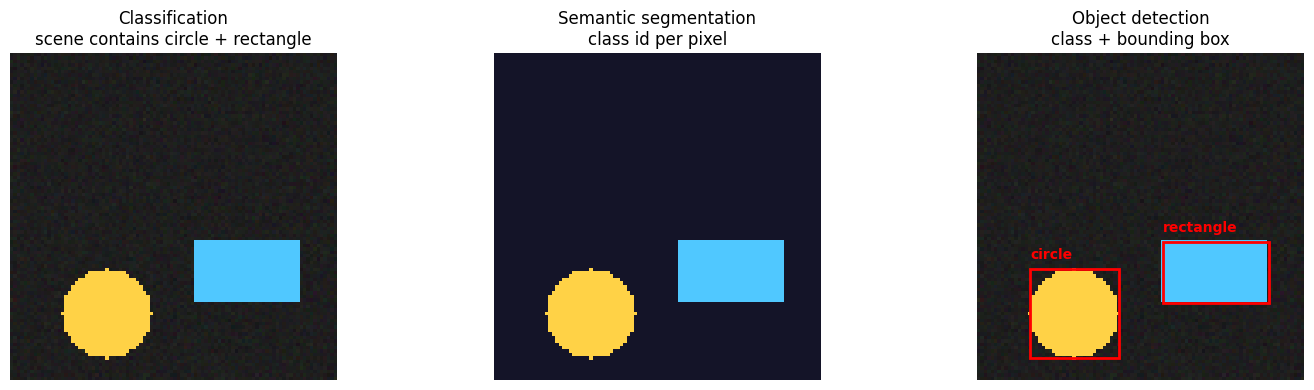

In [3]:
# TODO 1.8: tạo một ảnh mẫu bằng make_synthetic_scene(seed=10).
image, mask, boxes = make_synthetic_scene(seed=10)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Classification: chỉ cần nhãn cấp ảnh.
axes[0].imshow(image)
axes[0].set_title("Classification\nscene contains circle + rectangle")
axes[0].axis("off")

# Semantic segmentation: cần class id cho từng pixel.
axes[1].imshow(colorize_mask(mask))
axes[1].set_title("Semantic segmentation\nclass id per pixel")
axes[1].axis("off")

# Object detection: cần bounding box và class cho từng đối tượng.
axes[2].imshow(image)
for class_name, x1, y1, x2, y2 in boxes:
    # TODO 1.9: tạo Rectangle patch từ tọa độ bounding box.
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth = 2,
        edgecolor="red",
        facecolor="none"
    )
    axes[2].add_patch(rect)
    axes[2].text(x1, y1 - 3, class_name, color="red", fontsize=10, weight="bold")
axes[2].set_title("Object detection\nclass + bounding box")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 2. Tạo `tf.data.Dataset` cho segmentation

Trong segmentation, input là ảnh RGB còn target là mask class id. Vì mask lưu class id nguyên, ta sẽ dùng loss `sparse_categorical_crossentropy`.

In [4]:
def build_arrays(num_samples, seed_offset=0):
    """Sinh mảng ảnh và mask để đưa vào tf.data.Dataset."""
    images = []
    masks = []

    # TODO 2.1: lặp qua num_samples để sinh ảnh và mask.
    for i in range(num_samples):
        image, mask, _ = make_synthetic_scene(seed=seed_offset + i)
        images.append(image)
        masks.append(mask[..., np.newaxis])

    # TODO 2.2: chuyển list thành numpy array đúng dtype.
    images = np.array(images, dtype="uint8")
    masks = np.array(masks, dtype="uint8")
    return images, masks


TRAIN_SAMPLES = 240
VAL_SAMPLES = 60
BATCH_SIZE = 16

# TODO 2.3: sinh train_images/train_masks và val_images/val_masks.
train_images, train_masks = build_arrays(TRAIN_SAMPLES, seed_offset=0)
val_images, val_masks = build_arrays(VAL_SAMPLES, seed_offset=10_000)

# TODO 2.4: tạo train_ds bằng from_tensor_slices, shuffle, batch, prefetch.
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_masks))
train_ds = train_ds.shuffle(512, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# TODO 2.5: tạo val_ds bằng from_tensor_slices, batch, prefetch.
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_masks))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Train images:", train_images.shape)
print("Train masks:", train_masks.shape)

I0000 00:00:1781167938.405630   49843 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1199 MB memory:  -> device: 0, name: NVIDIA RTX A2000 8GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Train images: (240, 96, 96, 3)
Train masks: (240, 96, 96, 1)


## 3. Xây mô hình segmentation encoder-decoder

Yêu cầu:

- Input shape: `(96, 96, 3)`.
- Encoder: dùng `Conv2D(..., strides=2, padding="same")`.
- Decoder: dùng `Conv2DTranspose(..., strides=2, padding="same")`.
- Output: `Conv2D(NUM_CLASSES, ..., activation="softmax")`.

In [5]:
def build_segmentation_model(image_size=IMAGE_SIZE, num_classes=NUM_CLASSES):
    """Xây mô hình segmentation encoder-decoder nhỏ."""
    inputs = keras.Input(shape=(image_size, image_size, 3), name="input_image")

    # TODO 3.1: rescale pixel từ [0, 255] về [0, 1].
    x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)

    # TODO 3.2: encoder giảm kích thước 96 -> 48 -> 24 -> 12.
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu", name="encoder_conv_1")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu", name="encoder_conv_2")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu", name="encoder_conv_3")(x)

    # TODO 3.3: decoder phóng to 12 -> 24 -> 48 -> 96.
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu", name="decoder_deconv_1")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu", name="decoder_deconv_2")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu", name="decoder_deconv_3")(x)

    # TODO 3.4: layer cuối dự đoán num_classes tại từng pixel.
    outputs = layers.Conv2D(num_classes, 3, padding="same", activation="softmax", name="pixel_classifier")(x)
    return keras.Model(inputs, outputs, name="toy_segmentation_model")


seg_model = build_segmentation_model()

# TODO 3.5: compile model với Adam, sparse_categorical_crossentropy và accuracy.
seg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

seg_model.summary()

Model: "toy_segmentation_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv_1                │ (None, 24, 24, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv_2                │ (None, 48, 48, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv_3                │ (None, 96, 96, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_classifier (Conv2D)       │ (None, 96, 96, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS = 4

# EarlyStopping giúp dừng sớm nếu validation loss không cải thiện.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )
]

# TODO 3.6: huấn luyện model trên train_ds và val_ds.
history = seg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/4


I0000 00:00:1781168028.410385   65139 service.cc:153] XLA service 0x71be38049d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781168028.410425   65139 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A2000 8GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1781168028.488348   65139 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1781168028.711092   65139 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1781168028.950672   65139 cuda_dnn.cc:461] Loaded cuDNN version 92101


11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8255 - loss: 1.0535

I0000 00:00:1781168040.152284   65139 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8355 - loss: 1.0344

W0000 00:00:1781168040.821793   65131 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1781168042.739597   65131 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 405ms/step - accuracy: 0.8747 - loss: 0.9383 - val_accuracy: 0.8891 - val_loss: 0.7221
Epoch 2/4
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8914 - loss: 0.4284 - val_accuracy: 0.8891 - val_loss: 0.1933
Epoch 3/4
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8914 - loss: 0.1613 - val_accuracy: 0.8891 - val_loss: 0.1500
Epoch 4/4
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9212 - loss: 0.1365 - val_accuracy: 0.9443 - val_loss: 0.1193


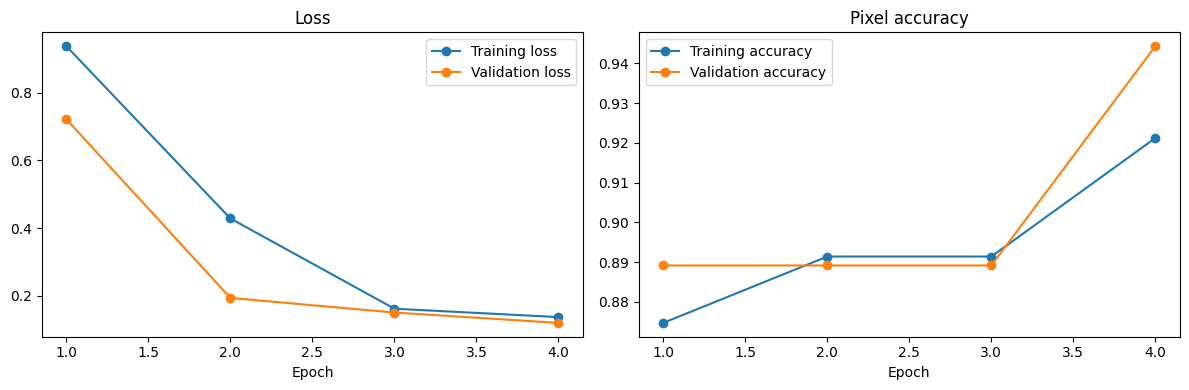

In [7]:
def plot_training_history(history):
    """Vẽ loss và accuracy để quan sát quá trình học."""
    metrics = history.history
    epochs = range(1, len(metrics["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # TODO 3.7: vẽ training loss và validation loss.
    axes[0].plot(epochs, metrics["loss"], "o-", label="Training loss")
    axes[0].plot(epochs, metrics["val_loss"], "o-", label="Validation loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # TODO 3.8: vẽ training accuracy và validation accuracy.
    axes[1].plot(epochs, metrics["accuracy"], "o-", label="Training accuracy")
    axes[1].plot(epochs, metrics["val_accuracy"], "o-", label="Validation accuracy")
    axes[1].set_title("Pixel accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


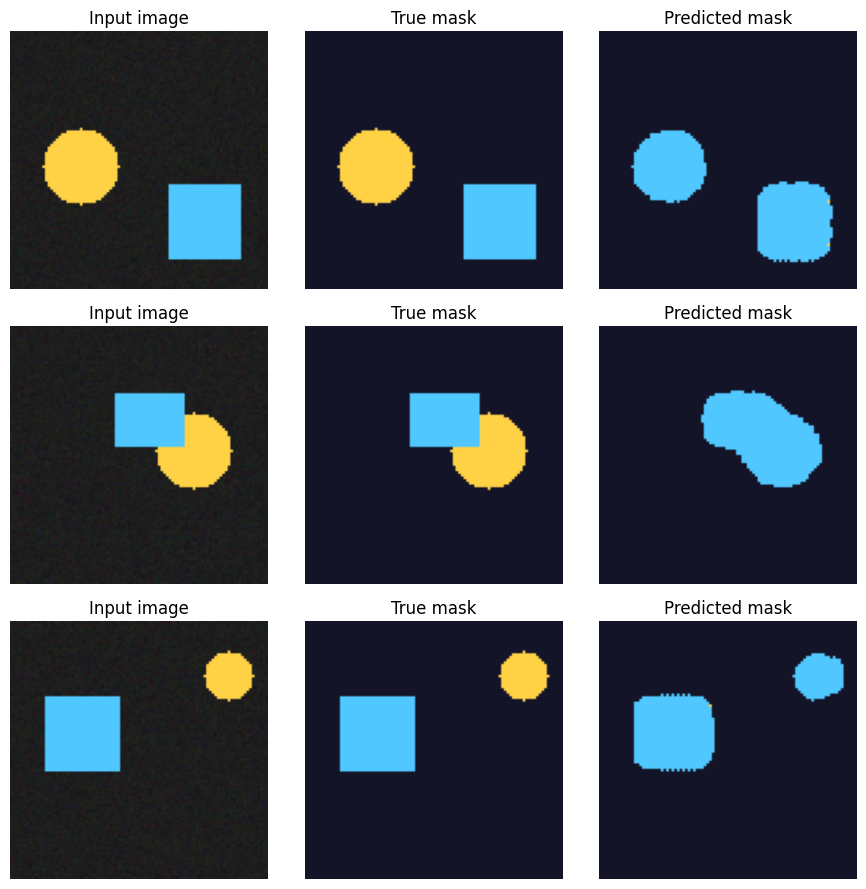

In [8]:
# Lấy một batch validation để xem model dự đoán mask.
sample_images, sample_masks = next(iter(val_ds))

# TODO 3.9: dự đoán xác suất class cho 3 ảnh đầu.
pred_probs = seg_model.predict(sample_images[:3])

# TODO 3.10: dùng argmax trên trục class để lấy mask dự đoán.
pred_masks = np.argmax(pred_probs, axis=-1).astype("uint8")

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i in range(3):
    axes[i, 0].imshow(sample_images[i].numpy().astype("uint8"))
    axes[i, 0].set_title("Input image")
    axes[i, 0].axis("off")

    true_mask = sample_masks[i].numpy().squeeze()
    axes[i, 1].imshow(colorize_mask(true_mask))
    axes[i, 1].set_title("True mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(colorize_mask(pred_masks[i]))
    axes[i, 2].set_title("Predicted mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## 4. Kiến trúc convnet hiện đại

Phần này thực hành ba ý tưởng trong sách:

- `SeparableConv2D` để giảm tham số.
- `BatchNormalization` để ổn định activation.
- Residual connection để tạo đường tắt thông tin: `$y = F(x) + x$`.

In [9]:
def count_params_for_layer(layer):
    """Tạo model một layer để đếm số tham số."""
    inputs = keras.Input(shape=(32, 32, 64))
    outputs = layer(inputs)
    model = keras.Model(inputs, outputs)
    return model.count_params()


# TODO 4.1: đếm tham số Conv2D chuẩn.
standard_params = count_params_for_layer(
    layers.Conv2D(64, 3, padding="same", use_bias=False)
)

# TODO 4.2: đếm tham số SeparableConv2D.
separable_params = count_params_for_layer(
    layers.SeparableConv2D(64, 3, padding="same", use_bias=False)
)

print("Số tham số Conv2D chuẩn:", standard_params)
print("Số tham số SeparableConv2D:", separable_params)
print("Tỉ lệ giảm tham số:", round(standard_params / separable_params, 2), "lần")

Số tham số Conv2D chuẩn: 36864
Số tham số SeparableConv2D: 4672
Tỉ lệ giảm tham số: 7.89 lần


In [10]:
def residual_block(x, filters, stride=1, name="residual_block"):
    """Residual block dùng Conv2D -> BN -> ReLU và shortcut projection khi cần."""
    residual = x

    # Nhánh chính học phần biến đổi F(x).
    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)

    # TODO 4.3: nếu shape thay đổi, dùng Conv2D 1x1 để projection shortcut.
    if residual.shape[-1] != filters or stride != 1:
        residual = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False, name=f"{name}_projection")(residual)

    # TODO 4.4: cộng nhánh chính với shortcut rồi đưa qua ReLU.
    x = layers.add([x, residual], name=f"{name}_add")
    x = layers.Activation("relu", name=f"{name}_out")(x)
    return x


inputs = keras.Input(shape=(64, 64, 3), name="input")
x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)
x = layers.Conv2D(32, 3, padding="same", use_bias=False, name="stem_conv")(x)
x = layers.BatchNormalization(name="stem_bn")(x)
x = layers.Activation("relu", name="stem_relu")(x)
x = residual_block(x, 32, stride=1, name="block1")
x = residual_block(x, 64, stride=2, name="block2")
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
outputs = layers.Dense(3, activation="softmax", name="classifier")(x)
residual_demo_model = keras.Model(inputs, outputs, name="residual_demo_model")

residual_demo_model.summary()

Model: "residual_demo_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input[0][0]       │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 64, 64,    │      9,216 │ stem_relu[0][0]   │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn1          │ (None, 64, 64,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu1        │ (None, 64, 64,    │          0 │ block1_bn1[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 64, 64,    │      9,216 │ block1_relu1[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 64, 64,    │        128 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 64, 64,    │          0 │ block1_bn2[0][0], │
│                     │ 32)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_out          │ (None, 64, 64,    │          0 │ block1_add[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 32, 32,    │     18,432 │ block1_out[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn1          │ (None, 32, 32,    │        256 │ block2_conv1[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_relu1        │ (None, 32, 32,    │          0 │ block2_bn1[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 32, 32,    │     36,864 │ block2_relu1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn2          │ (None, 32, 32,    │        256 │ block2_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                 

 Total params: 77,731 (303.64 KB)

 Trainable params: 77,283 (301.89 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
def xception_like_block(x, filters, stride=2, name="xception_like_block"):
    """Block kiểu Xception thu nhỏ dùng SeparableConv2D và residual projection."""
    residual = x

    # TODO 4.5: thêm BatchNorm -> ReLU -> SeparableConv2D lần 1.
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_sepconv1")(x)

    # TODO 4.6: thêm BatchNorm -> ReLU -> SeparableConv2D lần 2.
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_sepconv2")(x)

    # TODO 4.7: giảm mẫu bằng MaxPooling và tạo projection shortcut.
    x = layers.MaxPooling2D(3, strides=stride, padding="same", name=f"{name}_pool")(x)
    residual = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False, name=f"{name}_projection")(residual)

    # TODO 4.8: cộng hai nhánh.
    x = layers.add([x, residual], name=f"{name}_add")
    return x


inputs = keras.Input(shape=(96, 96, 3), name="input")
x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)
x = layers.Conv2D(32, 5, padding="same", use_bias=False, name="entry_conv")(x)

for filters in [32, 64, 128]:
    x = xception_like_block(x, filters, name=f"xception_block_{filters}")

x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.3, name="dropout")(x)
outputs = layers.Dense(2, activation="softmax", name="classifier")(x)
xception_demo_model = keras.Model(inputs, outputs, name="mini_xception_like_model")

xception_demo_model.summary()

Model: "mini_xception_like_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 96, 96, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ input[0][0]       │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv (Conv2D) │ (None, 96, 96,    │      2,400 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │        128 │ entry_conv[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │          0 │ xception_block_3… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │      1,312 │ xception_block_3… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │        128 │ xception_block_3… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │          0 │ xception_block_3… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │      1,312 │ xception_block_3… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 48, 48,    │          0 │ xception_block_3… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 48, 48,    │      1,024 │ entry_conv[0][0]  │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 48, 48,    │          0 │ xception_block_3… │
│ (Add)               │ 32)               │            │ xception_block_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │        128 │ xception_block_3… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │          0 │ xception_block_6… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │      2,336 │ xception_block_6… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │        256 │ xception_block_6… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │          0 │ xception_block_6… │
│ (Activation)        │ 64)               │            │                 

 Total params: 51,266 (200.26 KB)

 Trainable params: 50,562 (197.51 KB)

 Non-trainable params: 704 (2.75 KB)

## 5. Diễn giải convnet

Ta sẽ quan sát:

- **Intermediate activations**: feature maps của các layer trung gian.
- **Filter visualization**: pattern đầu vào làm một filter kích hoạt mạnh.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


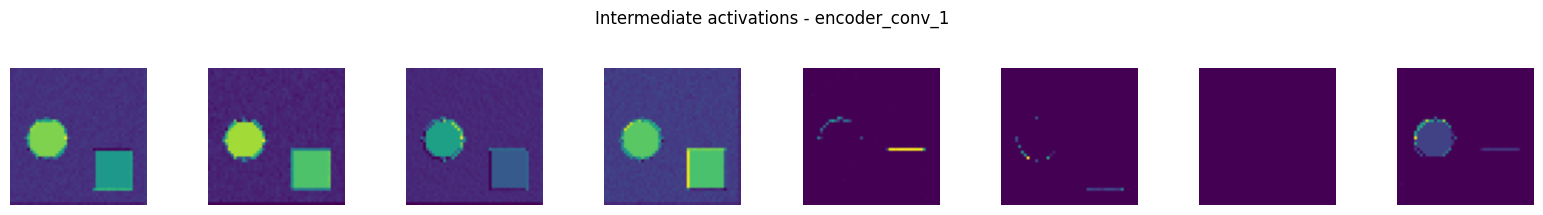

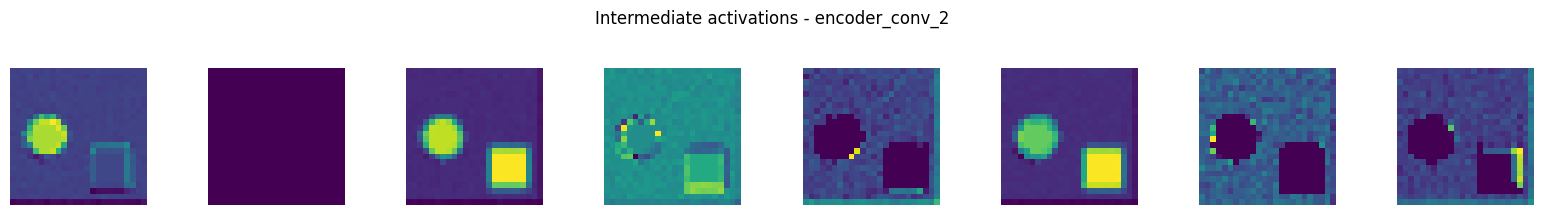

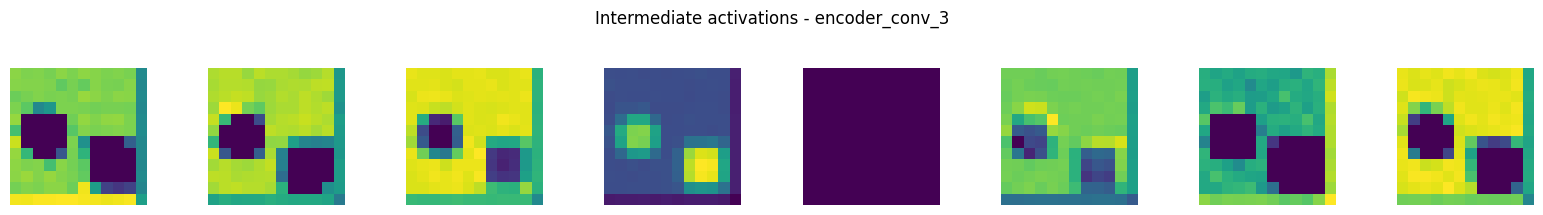

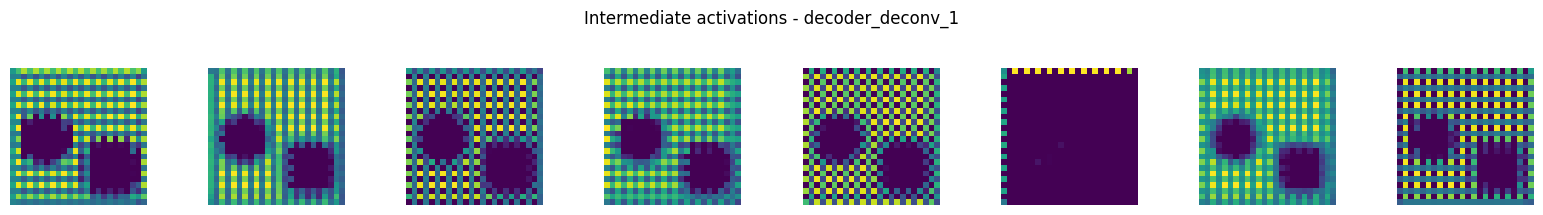

In [12]:
# Chọn một ảnh validation để đưa qua model segmentation đã train.
test_image = sample_images[:1]

# TODO 5.1: chọn một số layer convolution/deconvolution để quan sát.
layer_names = ["encoder_conv_1", "encoder_conv_2", "encoder_conv_3", "decoder_deconv_1"]

# TODO 5.2: tạo activation_model trả về output của các layer trên.
layer_outputs = [seg_model.get_layer(name).output for name in layer_names]
activation_model = keras.Model(seg_model.input, layer_outputs)

# TODO 5.3: dự đoán activation cho test_image.
activations = activation_model.predict(test_image)

for layer_name, activation in zip(layer_names, activations):
    num_channels = min(8, activation.shape[-1])
    fig, axes = plt.subplots(1, num_channels, figsize=(2 * num_channels, 2))
    fig.suptitle(f"Intermediate activations - {layer_name}", y=1.05)

    for channel_index in range(num_channels):
        # TODO 5.4: lấy một feature map 2D và chuẩn hóa để hiển thị.
        channel_image = activation[0, :, :, channel_index]
        channel_image = channel_image - channel_image.mean()
        channel_image = channel_image / (channel_image.std() + 1e-6)

        axes[channel_index].imshow(channel_image, cmap="viridis")
        axes[channel_index].axis("off")

    plt.tight_layout()
    plt.show()

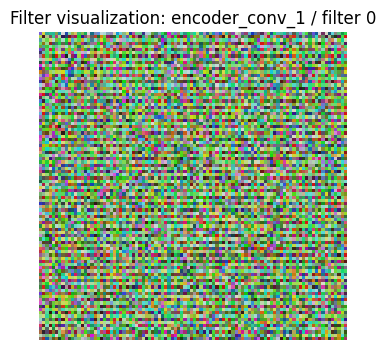

In [13]:
def deprocess_image(x):
    """Đưa tensor ảnh về dạng uint8 để hiển thị."""
    # TODO 5.5: chuẩn hóa ảnh quanh mean, scale lại và clip về [0, 255].
    x = x - x.mean()
    x = x / (x.std() + 1e-6)
    x = x * 64 + 128
    x = np.clip(x, 0, 255).astype("uint8")
    return x


def generate_filter_pattern(model, layer_name, filter_index=0, steps=40, learning_rate=10.0):
    """Tạo ảnh đầu vào làm một filter cụ thể kích hoạt mạnh bằng gradient ascent."""
    # TODO 5.6: tạo feature_extractor trả về activation của layer mục tiêu.
    feature_extractor = keras.Model(model.input, model.get_layer(layer_name).output)

    # TODO 5.7: khởi tạo ảnh ngẫu nhiên trong miền [0, 255].
    image = tf.Variable(tf.random.uniform((1, IMAGE_SIZE, IMAGE_SIZE, 3), minval=0, maxval=255))

    for step in range(steps):
        with tf.GradientTape() as tape:
            activation = feature_extractor(image)
            loss = tf.reduce_mean(activation[:, :, :, filter_index])

        # TODO 5.8: tính gradient, chuẩn hóa gradient và cập nhật ảnh theo gradient ascent.
        grads = tape.gradient(loss, image)
        grads = grads / (tf.sqrt(tf.reduce_mean(tf.square(grads))) + 1e-6)
        image.assign_add(learning_rate * grads)
        image.assign(tf.clip_by_value(image, 0, 255))

    return deprocess_image(image.numpy()[0])


pattern = generate_filter_pattern(seg_model, layer_name="encoder_conv_1", filter_index=0)

plt.figure(figsize=(4, 4))
plt.imshow(pattern)
plt.title("Filter visualization: encoder_conv_1 / filter 0")
plt.axis("off")
plt.show()

## Câu hỏi nộp bài

1. Trong demo này, tại sao segmentation mask có shape `(96, 96, 1)` thay vì `(96, 96, 3)`?
2. Vì sao segmentation dùng `Conv2DTranspose` trong decoder?
3. `SeparableConv2D` giảm tham số bằng cách nào?
4. Residual connection giúp giảm khó khăn gì khi mạng sâu?
5. Intermediate activations ở layer đầu và layer sâu khác nhau như thế nào?

**Trả lời:**

1. Do bài toán phân loại theo từng pixel (semantic segmentation), mỗi pixel chỉ cần 1 giá trị duy nhất đại diện cho Class ID (0, 1, hoặc 2) thay vì 3 kênh màu RGB.

2. `Conv2DTranspose` (upsampling) được dùng trong decoder để khôi phục kích thước không gian (chiều rộng và chiều cao) của feature map từ encoder trở lại bằng với kích thước ảnh gốc.

3. `SeparableConv2D` tách quá trình tích chập thông thường thành hai bước độc lập: **Depthwise Conv** (lọc không gian trên từng kênh) và **Pointwise Conv** (kết hợp các kênh qua nhân $1 \times 1$).

4. Residual connection giúp giải quyết vấn đề **tiêu biến đạo hàm (vanishing gradient)** bằng cách tạo đường truyền tắt (shortcut) cho phép gradient chảy trực tiếp về các lớp phía trước.

5. Intermediate activations ở các layer đầu thường trích xuất các đặc trưng hình học cơ bản (cạnh, góc, màu sắc), trong khi các layer sâu trích xuất các đặc trưng trừu tượng và mang tính ngữ nghĩa cao hơn (hình dạng, đối tượng cụ thể).